In [1]:
import torch
import faiss
import numpy as np

In [22]:
vs_img = faiss.read_index("../artifacts/vector_store/IC2026_image_faiss.index")

vs_txt = faiss.read_index("../artifacts/vector_store/IC2026_text_faiss.index")

In [4]:
train_emb = torch.load("../artifacts/embeddings/IC2026_medsiglip_train_image_embeddings.pt").numpy()
train_captions = torch.load("../artifacts/embeddings/IC2026_medsiglip_train_captions.pt")

valid_emb = torch.load("../artifacts/embeddings/IC2026_medsiglip_valid_image_embeddings.pt").numpy()
valid_captions = torch.load("../artifacts/embeddings/IC2026_medsiglip_valid_captions.pt")

In [5]:
import json 

with open("../artifacts/datasets/imageclef2026_train_dataset.json", 'r') as file:
    # Use json.load() to parse the file content into a Python object
    train_ds = json.load(file)

with open("../artifacts/datasets/imageclef2026_valid_dataset.json", 'r') as file:
    # Use json.load() to parse the file content into a Python object
    valid_ds = json.load(file)

In [6]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(
        ["rouge1"],
        use_stemmer=False
    )

In [26]:
i=2
D, I = vs_txt.search(valid_emb[i].reshape(1, -1).astype(np.float32), k=3)

print('True caption: \n')
ref = valid_captions[i]
print(ref)
print('\nTop 3 RAG captions: \n')
for idx in I[0]:
    pred = train_captions[idx]
    print(pred)
    print(scorer.score(ref, pred)['rouge1'].fmeasure)

True caption: 

Sagittal STIR sequence of the lumbar spine showing hyperintensity signal of the L1/L2 intervertebral disc and the vertebral bodies of L1 and L2 with an epidural abscess, resulting in compression of the dura sack (white arrow)

Top 3 RAG captions: 

T2 weighted sagittal magnetic resonance imaging scan of the lumbar spine showing a compression fracture in L2 and an enhancing expansile mass (arrow) in the L1 spinous process.
0.4307692307692308
Sagittal view of T2 diffusion MRI lumbar spine showing extensive epidural abscess (arrow) extending from the upper dorsal region all the way to the distal conus medullaris, displacing the thecal sac.
0.3529411764705882
Sagittal T2-weighted MRI of woman with normal lumbar segmentation shows that conus medullaris (arrow) is located at L1 body.
0.2105263157894737


In [27]:
from tqdm import tqdm

scores = []
for i in tqdm(range(valid_emb.shape[0])):
    query_emb = valid_emb[i].reshape(1, -1).astype(np.float32)
    faiss.normalize_L2(query_emb)

    D, I = vs_txt.search(query_emb, k=1)
    ref = valid_captions[i]
    pred = train_captions[I[0][0]]

    scores.append(scorer.score(ref, pred)['rouge1'].fmeasure)

100%|██████████| 19240/19240 [03:04<00:00, 104.56it/s]


In [28]:
print(f"Mean ROUGE1 score (validation): {sum(scores)/len(scores)}")

Mean ROUGE1 score (validation): 0.18830261094034487


In [11]:
print(f"Mean ROUGE1 score (validation): {sum(scores)/len(scores)}")

Mean ROUGE1 score (validation): 0.1821009675117927


True caption: 

Chest radiograph of the second right-sided pneumothorax more extensive involving the right upper lobe (black arrow).

Top 3 RAG captions: 

Chest radiograph of first pneumothorax located in the right upper lobe (black arrow).
0.6666666666666667
Postoperative plain X-ray showing improvement in the scoliosis.
0.07692307692307691
Chest X-ray showing collapsed lung and pneumothorax (white arrows)
0.14814814814814817


/tmp/ipykernel_189506/4142921633.py:16: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img1 = imageio.imread(train_ds[I[0][0]]['image_path'])
/tmp/ipykernel_189506/4142921633.py:17: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img2 = imageio.imread(valid_ds[i]['image_path'])


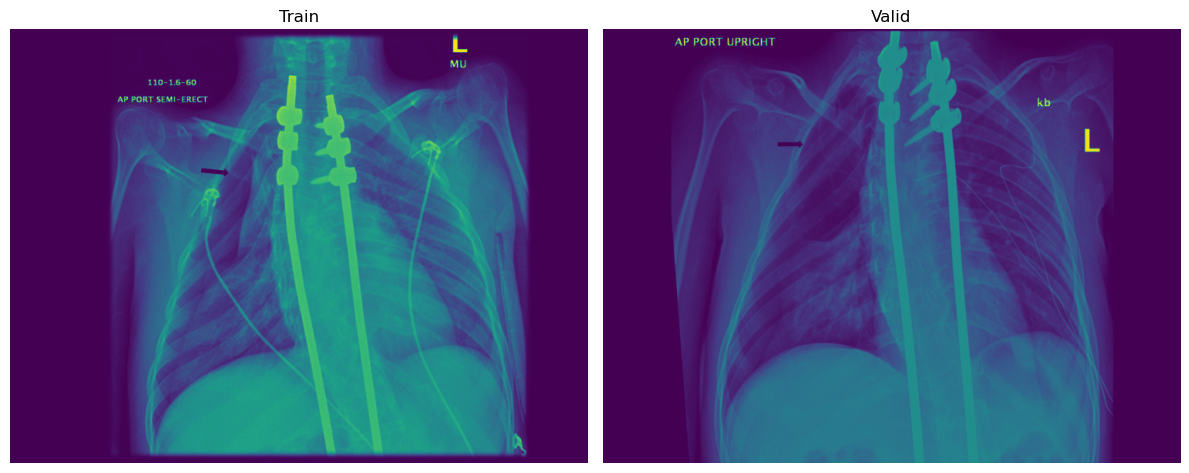

In [77]:
i=127
D, I = vs_img.search(valid_emb[i].reshape(1, -1).astype(np.float32), k=3)

print('True caption: \n')
ref = valid_captions[i]
print(ref)
print('\nTop 3 RAG captions: \n')
for idx in I[0]:
    pred = train_captions[idx]
    print(pred)
    print(scorer.score(ref, pred)['rouge1'].fmeasure)

import imageio
import matplotlib.pyplot as plt

img1 = imageio.imread(train_ds[I[0][0]]['image_path'])
img2 = imageio.imread(valid_ds[i]['image_path'])

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, img, title in zip(axes, (img1, img2), ("Train", "Valid")):
    if img.ndim == 2:
        ax.imshow(img)
    else:
        ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
# fig.savefig("comparison.png", dpi=300, bbox_inches='tight')  # opcional
plt.show()

/tmp/ipykernel_189506/3927045967.py:4: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img1 = imageio.imread(train_ds[I[0][0]]['image_path'])
/tmp/ipykernel_189506/3927045967.py:5: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img2 = imageio.imread(valid_ds[i]['image_path'])


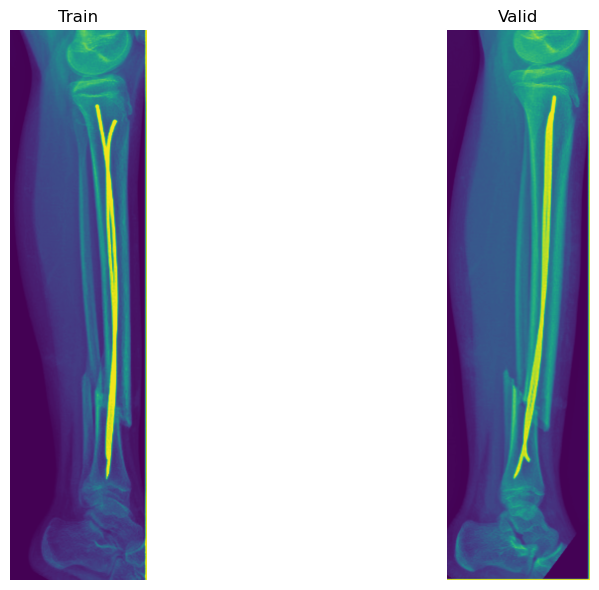

In [73]:
import imageio
import matplotlib.pyplot as plt

img1 = imageio.imread(train_ds[I[0][0]]['image_path'])
img2 = imageio.imread(valid_ds[i]['image_path'])

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, img, title in zip(axes, (img1, img2), ("Train", "Valid")):
    if img.ndim == 2:
        ax.imshow(img)
    else:
        ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
# fig.savefig("comparison.png", dpi=300, bbox_inches='tight')  # opcional
plt.show()

In [ ]:
train_ds = 